# Project: Stock Data Extraction and Visualization

This project demonstrates the process of extracting and visualizing financial data for two publicly traded companies: **Tesla (TSLA)** and **GameStop (GME)**.

The analysis involves two primary methods of data collection:
1.  **Stock Price History:** Using the `yfinance` library to fetch historical stock market data (Open, High, Low, Close) directly from the Yahoo Finance API.
2.  **Revenue Data:** Using `pandas` and `BeautifulSoup` to perform web scraping on financial websites to extract quarterly revenue data.

Finally, the `plotly` library is used to create interactive dashboard-style charts, plotting the historical share price alongside the quarterly revenue for each company to observe potential correlations and trends.

Extracting essential data from a dataset and displaying it is a necessary part of data science; therefore individuals can make correct decisions based on the data.

## Setup

Install necessary Python libraries for this project.

In [27]:
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install --upgrade plotly
! pip install --upgrade kaleido


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


### Import Libraries

Import the libraries that will be used in this notebook.

In [28]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [29]:
import plotly.io as pio
pio.renderers.default = "notebook"

In Python, you can ignore warnings using the warnings module. You can use the filterwarnings function to filter or ignore specific warning messages or categories.

In [30]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Define Graphing Function


Define a helper function `make_graph` to plot the stock data and revenue data on the same chart.

In [31]:
def make_graph(stock_data, revenue_data, stock):
    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True,
        subplot_titles=("Historical Share Price", "Historical Revenue"),
        vertical_spacing=0.3
    )

    # Filter dates
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    # Add traces
    fig.add_trace(
        go.Scatter(
            x=pd.to_datetime(stock_data_specific.Date),
            y=stock_data_specific.Close.astype("float"),
            name="Share Price"
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Scatter(
            x=pd.to_datetime(revenue_data_specific.Date),
            y=revenue_data_specific.Revenue.astype("float"),
            name="Revenue"
        ),
        row=2, col=1
    )

    # Axis labels
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($US)", row=1, col=1)
    fig.update_yaxes(title_text="Revenue ($US Millions)", row=2, col=1)

    # Layout
    fig.update_layout(
        showlegend=False,
        height=900,
        title=stock,
        xaxis_rangeslider_visible=True
    )

    # --- Create PNG and embed into notebook output ---
    import base64
    import io
    from IPython.display import Image, display

    buf = io.BytesIO()
    fig.write_image(buf, format="png")
    buf.seek(0)

    display(Image(data=buf.read()))


## 1. Extracting Tesla (TSLA) Stock Data using yfinance


First, we create a Ticker object for Tesla (TSLA).

In [32]:
tesla=yf.Ticker('TSLA')

Next, we extract the stock information using the `history` function and set the `period` to `max`.

In [33]:
tesla_data=tesla.history(period='max')

Reset the index and display the first five rows of the `tesla_data` dataframe.

In [34]:
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## 2. Extracting Tesla Revenue Data using Webscraping


Download the webpage containing the revenue data using the `requests` library.

In [35]:
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data=requests.get(url).text

Parse the HTML data using `BeautifulSoup`.

In [36]:
soup=BeautifulSoup(html_data,'html.parser')

Extract the table with `Tesla Quarterly Revenue` and store it in a dataframe named `tesla_revenue`.

In [37]:
tesla_revenue=pd.DataFrame(columns=['Date','Revenue'])

tabind=0

tables=soup.find_all('table')

for i,row in enumerate(tables):
    if('Tesla Quarterly Revenue' in str(row)):
        tabind=i

for row in tables[tabind].tbody.find_all('tr'):
    col=row.find_all('td')

    if col:
        date=col[0].text
        revenue=col[1].text

    newrow=pd.DataFrame([{'Date':date,'Revenue':revenue}])

    tesla_revenue=pd.concat([tesla_revenue,newrow], ignore_index=True)

tesla_revenue.head()

,Date,Revenue
0,2022-09-30,"$21,454"
1,2022-06-30,"$16,934"
2,2022-03-31,"$18,756"
3,2021-12-31,"$17,719"
4,2021-09-30,"$13,757"


Remove the comma and dollar sign from the `Revenue` column.

In [38]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True)

<>:1: SyntaxWarning:

"\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.

<>:1: SyntaxWarning:

"\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.

C:\Users\Asus\AppData\Local\Temp\ipykernel_26948\3152827612.py:1: SyntaxWarning:

"\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.



Remove any null or empty strings in the `Revenue` column.

In [39]:
tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

Display the last 5 rows of the `tesla_revenue` dataframe.

In [40]:
tesla_revenue.tail()

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


## 3. Extracting GameStop (GME) Stock Data using yfinance


Create a Ticker object for GameStop (GME).

In [41]:
gamestop=yf.Ticker("GME")

Extract the stock information for GameStop.

In [42]:
gme_data=gamestop.history(period="max")

Reset the index and display the first five rows of the `gme_data` dataframe.

In [43]:
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578048,1.607505,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


## 4. Extracting GameStop Revenue Data using Webscraping


Download the webpage containing GameStop's revenue data.

In [44]:
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2=requests.get(url).text

Parse the HTML data.

In [45]:
soup=BeautifulSoup(html_data_2,'html.parser')

Extract the table with `GameStop Quarterly Revenue` and store it in `gme_revenue`. Clean the `Revenue` column by removing commas, dollar signs, and null/empty values.

In [46]:
gme_revenue=pd.DataFrame(columns=['Date','Revenue'])

tabind=0

tables=soup.find_all('table')

for i,row in enumerate(tables):
    if('GameStop Quarterly Revenue' in str(row)):
        tabind=i

for row in tables[tabind].tbody.find_all('tr'):
    col=row.find_all('td')

    if col:
        date=col[0].text
        revenue=col[1].text

    newrow=pd.DataFrame([{'Date':date,'Revenue':revenue}])

    gme_revenue=pd.concat([gme_revenue,newrow], ignore_index=True)

# gme_revenue.head(2)

gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$',"",regex=True)


gme_revenue.dropna(inplace=True)

gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

<>:24: SyntaxWarning:

"\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.

<>:24: SyntaxWarning:

"\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.

C:\Users\Asus\AppData\Local\Temp\ipykernel_26948\1288469459.py:24: SyntaxWarning:

"\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.



Display the last five rows of the `gme_revenue` dataframe.

In [47]:
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


## 5. Plotting Tesla Stock and Revenue


Use the `make_graph` function to plot the Tesla stock data and revenue.

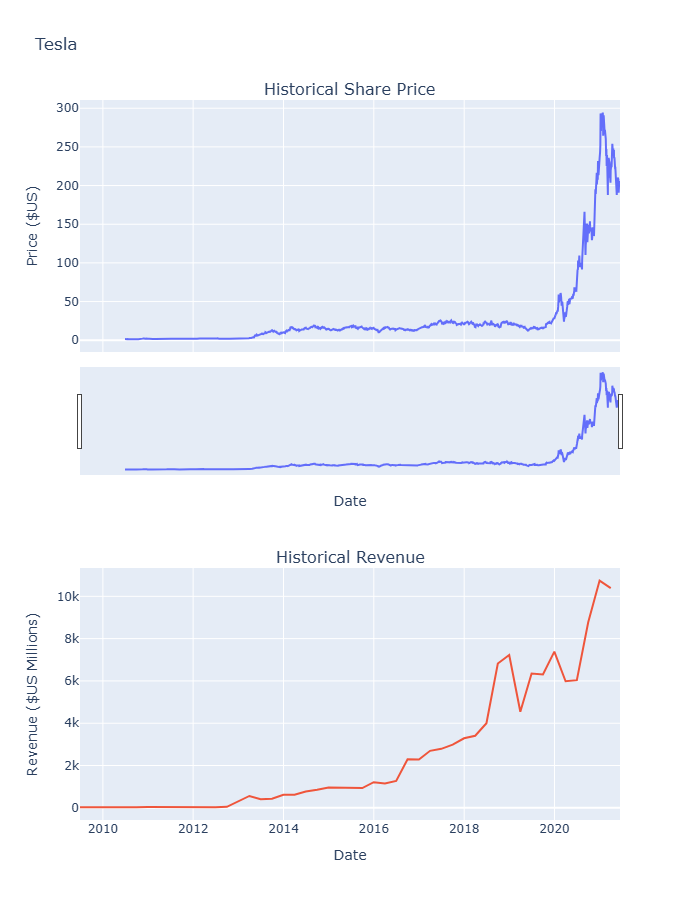

In [48]:
make_graph(tesla_data, tesla_revenue, 'Tesla')


## 6. Plotting GameStop Stock and Revenue


Use the `make_graph` function to plot the GameStop stock data and revenue.

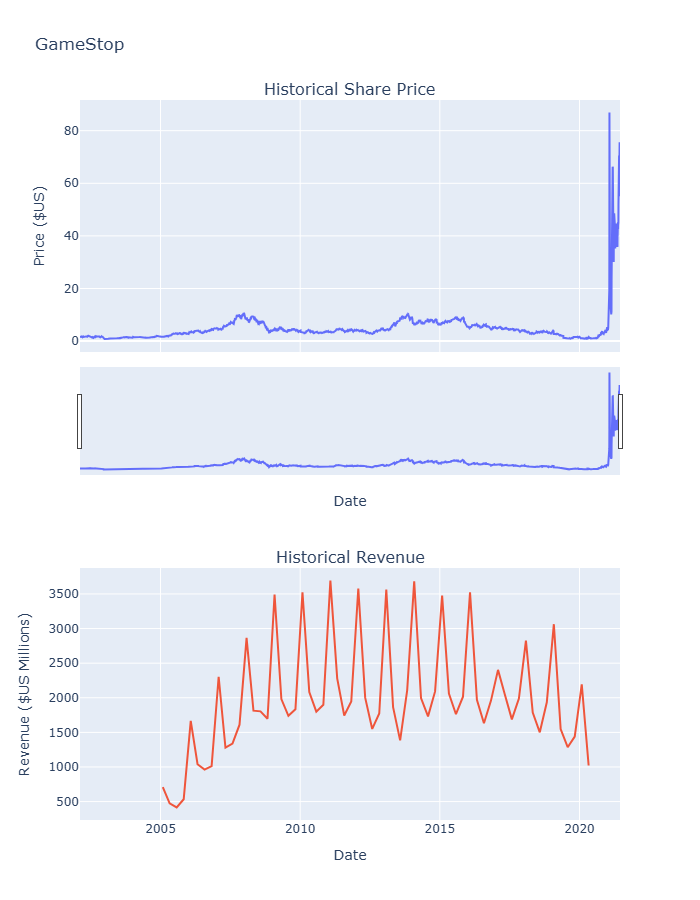

In [49]:
make_graph(gme_data, gme_revenue, 'GameStop')

# Conclusion

This project successfully demonstrated the extraction of financial data from two distinct sources: the `yfinance` API for historical stock prices and web scraping with `BeautifulSoup` for quarterly revenue data.

By visualizing the data for both **Tesla (TSLA)** and **GameStop (GME)**, we can observe the complex relationship between a company's fundamental financial performance and its market valuation:

* **For Tesla**, the plots show a general upward trend in both revenue and stock price over the long term. However, the stock price displays significantly more volatility and exponential growth, suggesting that its valuation is heavily influenced by market sentiment, future expectations, and news events, not just its reported revenue.

* **For GameStop**, the visualization starkly highlights a near-total disconnect between stock price and revenue. The massive, unprecedented spike in its stock price had no correlation with the company's steady (or declining) quarterly revenue, clearly illustrating how market dynamics, retail trading (meme-stock phenomenon), and short squeezes can overshadow a company's fundamental financial performance.

In essence, this analysis confirms that while revenue is a key metric, it is only one of many factors that drive stock prices in the modern market.